In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import brainmass
import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Quickstart

This 5-minute tutorial demonstrates the basic `brainmass` workflow: create a neural mass model,
add noise, simulate dynamics, and visualize results.

:::{note}
Every code block on this page is executed as part of the documentation build
(via `sphinx.ext.doctest`), so the snippets are guaranteed to run against the
current API. The integration time step `dt` is a global set through
`brainstate.environ` -- it is **not** a model argument.
:::

## Your First Simulation

Let's simulate a single brain region using the Hopf oscillator model:

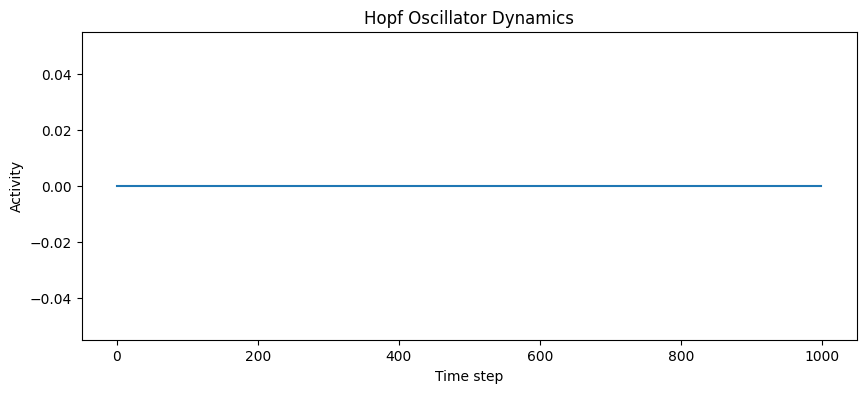

In [2]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt

# dt is global state, set once through the environment
brainstate.environ.set(dt=0.1 * u.ms)

# 1. Create a Hopf oscillator in the limit-cycle regime
model = brainmass.HopfStep(
    in_size=1,   # single region
    a=0.25,      # bifurcation parameter (>0 -> self-sustained oscillation)
    w=0.2,       # intrinsic angular frequency (dimensionless)
)

# 2. Initialize the model state
model.init_all_states()

# 3. Run the simulation for 1000 time steps, recording x each step
def step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        model.update()
        return model.x.value

time_series = brainstate.transform.for_loop(step, np.arange(1000))

# 4. Visualize (time_series has shape (1000, 1))
plt.figure(figsize=(10, 4))
plt.plot(time_series[:, 0])  # plot the x coordinate
plt.xlabel('Time step')
plt.ylabel('Activity')
plt.title('Hopf Oscillator Dynamics')
plt.show()

**What's happening:**

- `a > 0` puts the oscillator in the limit-cycle (self-sustained oscillation) regime
- `w` is the intrinsic angular frequency (dimensionless in this normal-form model)
- `brainstate.environ.context(i=, t=)` supplies the step index/time the update needs
- `for_loop` efficiently runs 1000 simulation steps
- the output is a `(1000, 1)` array of the oscillator's x-coordinate

## Adding Noise

Real neural activity is noisy. Attach Ornstein-Uhlenbeck noise processes when you
construct the model. The XY-family oscillators expect a noise process for *both*
components, and -- because the Hopf state is dimensionless -- `sigma` is dimensionless too:

In [3]:
import brainmass
import brainstate
import brainunit as u
import numpy as np

brainstate.environ.set(dt=0.1 * u.ms)

model = brainmass.HopfStep(
    in_size=1, a=0.25, w=0.2,
    noise_x=brainmass.OUProcess(in_size=1, sigma=0.05, tau=20. * u.ms),
    noise_y=brainmass.OUProcess(in_size=1, sigma=0.05, tau=20. * u.ms),
)

# init_all_states also initializes the attached noise sub-modules
brainstate.nn.init_all_states(model)

def step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        model.update()
        return model.x.value

time_series = brainstate.transform.for_loop(step, np.arange(1000))

The noise is added automatically inside `update()`, creating more realistic fluctuations.

## Multi-Region Networks

Simulate multiple brain regions simultaneously by setting `in_size` to the number
of regions. Here the regions are independent (no coupling yet):

In [4]:
import brainmass
import brainstate
import brainunit as u
import numpy as np

brainstate.environ.set(dt=0.1 * u.ms)
N_regions = 10

# A bank of Wilson-Cowan models with per-population noise
network = brainmass.WilsonCowanStep(
    in_size=N_regions,
    tau_E=10. * u.ms,
    tau_I=20. * u.ms,
    noise_E=brainmass.OUProcess(in_size=N_regions, sigma=0.1, tau=20. * u.ms),
    noise_I=brainmass.OUProcess(in_size=N_regions, sigma=0.1, tau=30. * u.ms),
)
brainstate.nn.init_all_states(network)

def step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return network.update(rE_inp=0.5, rI_inp=0.2)

# exc_rates has shape (2000, 10) - excitatory rates for 10 regions
exc_rates = brainstate.transform.for_loop(step, np.arange(2000))

**Note:** `in_size=N_regions` creates `N` independent copies of the model (no coupling yet).

## Adding Coupling

To connect regions, build a coupling term from a connectivity matrix. `DiffusiveCoupling`
reads each node's state through a *prefetch* (optionally delayed), multiplies by the
connectivity, and returns a per-node current you feed back into `update`:

In [5]:
import brainmass
import brainstate
import braintools
import brainunit as u
import numpy as np
import jax.numpy as jnp

brainstate.environ.set(dt=0.1 * u.ms)
N = 10

nodes = brainmass.HopfStep(in_size=N, a=0.25, w=0.3)

# Connectivity matrix (random for demo), no self-connections
W = np.random.RandomState(0).rand(N, N) * 0.1
np.fill_diagonal(W, 0.0)
W = jnp.asarray(W)

# Each target node reads every source node's (delayed) ``x`` -> shape (N, N)
delays = jnp.ones((N, N)) * (1.0 * u.ms)
src_idx = np.tile(np.arange(N)[None, :], (N, 1))
x_delayed = nodes.prefetch_delay('x', delays, src_idx, init=braintools.init.Constant(0.0))
x_local = nodes.prefetch('x')

coupling = brainmass.DiffusiveCoupling(x_delayed, x_local, conn=W, k=0.2)

brainstate.nn.init_all_states(nodes)
brainstate.nn.init_all_states(coupling)  # the coupling owns the delay buffer

def network_step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        coupled_input = coupling.update()    # (N,) coupling current
        nodes.update(coupled_input, 0.0)     # feed it as the x input
        return nodes.x.value

network_activity = brainstate.transform.for_loop(network_step, np.arange(1000))

## Forward Modeling (BOLD Signal)

Map neural activity to an fMRI BOLD signal with the Balloon-Windkessel `BOLDSignal` model.
The neural model integrates with a `dt` carrying time units, while `BOLDSignal` is fully
dimensionless and expects a **unitless** `dt` -- so the two stages set `dt` separately:

In [6]:
import brainmass
import brainstate
import brainunit as u
import numpy as np

N_regions = 5

# --- neural stage (dt carries time units) ---
brainstate.environ.set(dt=0.1 * u.ms)
nmm = brainmass.WilsonCowanStep(in_size=N_regions)
nmm.init_all_states()

def sim_neural(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return nmm.update(rE_inp=0.5, rI_inp=0.2)

neural_activity = brainstate.transform.for_loop(sim_neural, np.arange(2000))

# --- haemodynamic stage (BOLDSignal needs a dimensionless dt) ---
brainstate.environ.set(dt=0.01)
bold_model = brainmass.BOLDSignal(in_size=N_regions)
bold_model.init_all_states()

def sim_bold(z):
    bold_model.update(z)        # update() returns None; it mutates state
    return bold_model.bold()    # read the BOLD observable

bold_signal = brainstate.transform.for_loop(sim_bold, neural_activity)
# bold_signal has shape (2000, 5)

brainstate.environ.set(dt=0.1 * u.ms)  # restore the time-unit dt for later code

## Common Patterns

**Pattern 1: Batched Simulations**

Run multiple independent simulations in parallel with `batch_size`:

In [7]:
brainstate.environ.set(dt=0.1 * u.ms)
batch_size = 32

model = brainmass.HopfStep(in_size=10, w=0.2)
model.init_all_states(batch_size=batch_size)

model.update()
x = model.x.value  # shape: (32, 10)

**Pattern 2: Accessing Internal States**

In [8]:
model = brainmass.WilsonCowanStep(in_size=5)
model.init_all_states()

model.update(rE_inp=0.5, rI_inp=0.2)

# Access internal state variables
exc_rate = model.rE.value  # excitatory firing rate, shape (5,)
inh_rate = model.rI.value  # inhibitory firing rate, shape (5,)

**Pattern 3: Custom Time Steps**

In [9]:
# dt is global; set it through the environment (not a model argument)
brainstate.environ.set(dt=0.5 * u.ms)

model = brainmass.HopfStep(in_size=1, w=0.2)
model.init_all_states()

NewStateCatcher(
  state_to_exclude=Nothing(),
  state_tag=None,
  state_ids={140188940394016, 140188478767904},
  states=[
    HiddenState(
      value=ShapedArray(float32[1], weak_type=True)
    ),
    HiddenState(
      value=ShapedArray(float32[1], weak_type=True)
    )
  ]
)

## Quick Reference

| Task | Code |
| --- | --- |
| Set the time step | `brainstate.environ.set(dt=0.1 * u.ms)` |
| Create model | `model = brainmass.HopfStep(in_size=N, **params)` |
| Initialize state | `model.init_all_states(batch_size=None)` |
| Single step | `output = model.update(**inputs)` |
| Simulate loop | `brainstate.transform.for_loop(step, jnp.arange(T))` |
| Add noise | `brainmass.HopfStep(in_size=N, noise_x=..., noise_y=...)` |
| Access state | `value = model.state_var.value` |
| Reset state | `model.reset_state()` |

## Next Steps

Now that you've run your first simulations:

1. {doc}`choosing_models` - Learn which model to use for your application
2. {doc}`building_networks` - Create realistic multi-region networks
3. {doc}`parameter_fitting` - Optimize parameters to match empirical data
4. {doc}`../examples/index` - Explore complete examples

## Tips for Beginners

- **Start simple:** Single region, no noise, no coupling
- **Visualize often:** Plot time series to understand dynamics
- **Check units:** Use `brainunit` quantities to avoid unit errors
- **Read docstrings:** Use `help(brainmass.HopfStep)` for parameter details
- **Use examples:** The {doc}`../examples/index` are your best resource

## See Also

- {doc}`../apis/models` - Complete model reference
- {doc}`../apis/noise` - Noise processes documentation
- {doc}`../apis/coupling` - Coupling mechanisms
- {doc}`../apis/forward` - Forward models